# 03 모델 개발 및 평가 (DAY 2)

**실험 설계**
- 학습: Batch 1 (Train 80% / Valid Hold-out 20%)
- 평가: Batch 2 (Test, 필수) · Batch 3 (Additional)
- 태스크: Regression — Cycle Life 예측
- 지표: MAPE (원논문 목표 ≤ 9.1%, 단 원논문은 배치 혼합 학습 기준)
- 모델: ElasticNet · GBM · RF (DAY 1 설계서 선정)
- 핵심 피처: `var_log_dQ = log₁₀(Var(ΔQ(V)))` — Severson 2019 원식


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_absolute_error

from src.preprocess import load_batch_features
from src.features import FEATURES, TARGET_MAPE, PROJECT_ROOT
from src.train import split_batches, train_and_evaluate, compute_gaps, save_summary

_fp = fm.findSystemFonts()
_n = [f for f in _fp if 'NanumGothic' in f or 'nanumgothic' in f.lower()]
if _n:
    plt.rcParams['font.family'] = fm.FontProperties(fname=_n[0]).get_name()
plt.rcParams['axes.unicode_minus'] = False

OUT = str(PROJECT_ROOT / 'results')
print('환경 설정 완료')

환경 설정 완료


## 1. 데이터 로드 및 분할

In [2]:
print('피처 추출 중 (약 2~3분)...')
df = load_batch_features(verbose=True)

train_df, valid_df, b2, b3 = split_batches(df)
print(f'\n데이터 분할:')
print(f'  Train  (B1 80%): {len(train_df)}셀  수명 {train_df.cycle_life.min():.0f}~{train_df.cycle_life.max():.0f}')
print(f'  Valid  (B1 20%): {len(valid_df)}셀  수명 {valid_df.cycle_life.min():.0f}~{valid_df.cycle_life.max():.0f}')
print(f'  Test   (B2)    : {len(b2)}셀  수명 {b2.cycle_life.min():.0f}~{b2.cycle_life.max():.0f}')
print(f'  Test3  (B3)    : {len(b3)}셀  수명 {b3.cycle_life.min():.0f}~{b3.cycle_life.max():.0f}')

피처 추출 중 (약 2~3분)...
  로딩: B1
  로딩: B2
  로딩: B3
  총 113셀 (NaN 제거 후)
  배치별: {'B1': 36, 'B2': 33, 'B3': 44}

데이터 분할:
  Train  (B1 80%): 28셀  수명 534~1074
  Valid  (B1 20%): 8셀  수명 559~1051
  Test   (B2)    : 33셀  수명 392~1186
  Test3  (B3)    : 44셀  수명 541~1935


## 2. 모델 학습 및 평가

In [3]:
print('모델 학습 중...')
results, (y_train, y_valid, y_test2, y_test3) = train_and_evaluate(train_df, valid_df, b2, b3)
results = compute_gaps(results)

# Baseline: Train 평균값 상수 예측
train_mean = np.mean(y_train)
def _m(yt, yp): return {'mape': mean_absolute_percentage_error(yt,yp)*100,
                         'r2': r2_score(yt,yp), 'mae': mean_absolute_error(yt,yp)}
baseline = {
    'cv':    {**_m(y_train, np.full_like(y_train, train_mean))},
    'valid': {**_m(y_valid, np.full_like(y_valid, train_mean))},
    'test2': {**_m(y_test2, np.full_like(y_test2, train_mean))},
    'test3': {**_m(y_test3, np.full_like(y_test3, train_mean))},
}
baseline['gaps'] = {
    'train_valid': baseline['valid']['mape']  - baseline['cv']['mape'],   # +6.56%p
    'valid_test':  baseline['test2']['mape'] - baseline['valid']['mape'],
    'target_test': baseline['test2']['mape'] - TARGET_MAPE,
    'b2_b3':       baseline['test3']['mape'] - baseline['test2']['mape'],
    'target_test_b3': baseline['test3']['mape'] - TARGET_MAPE,
}
print('완료')

모델 학습 중...


완료


## 3. 성능 리포팅 테이블 (Baseline 포함)

In [4]:
MODEL_NAMES = ['ElasticNet', 'GBM', 'RF']
ALL = {'Baseline': baseline, **results}
sep = '='*100

def frow(label, key, subkey, indent=''):
    vals = [ALL[m][key][subkey] for m in ['Baseline']+MODEL_NAMES]
    return f'{indent}{label:<25}' + ''.join(f'{v:>12.2f}%' for v in vals)

def fgap(label, key):
    vals = [ALL[m]['gaps'][key] for m in ['Baseline']+MODEL_NAMES]
    return f'  {label:<23}' + ''.join(f'{v:>+11.2f}%p' for v in vals)

header = f'  {"":25}' + ''.join(f'{m:>12}' for m in ['Baseline']+MODEL_NAMES)
print(sep)
print(header)
print('-'*100)
print(frow('Train (Batch 1 CV)', 'cv', 'mape'))
print(frow('Valid (Batch 1 H-O)', 'valid', 'mape'))
print(frow('Test  (Batch 2)', 'test2', 'mape'))
print(fgap('Gap (Train-Valid)', 'train_valid') + '   (+): 과적합 의심')
print(fgap('Gap (Valid-Test)', 'valid_test')  + '   (+): 일반화 저하')
print(fgap('Gap (Target-Test)', 'target_test') + f'   Target: {TARGET_MAPE}%')
print('-'*100)
print(frow('Test  (Batch 3)', 'test3', 'mape') + '   [additional]')
print(fgap('Gap (Batch2-Batch3)', 'b2_b3'))
print(fgap('Gap (Target-Test B3)', 'target_test_b3') + f'   Target: {TARGET_MAPE}%')
print(sep)

# Valid 기준 최적 모델 선택 (Test 데이터 미사용)
best_name = min(results, key=lambda k: results[k]['valid']['mape'])
print(f'\n최적 모델 (Valid MAPE 기준): {best_name} ({results[best_name]["valid"]["mape"]:.2f}%)')
print(f'  ※ 원논문 9.1%는 B1+B2+B3 혼합 학습 기준 — 본 실험은 B1 단독 학습으로 직접 비교 불가')

                               Baseline  ElasticNet         GBM          RF
----------------------------------------------------------------------------------------------------
Train (Batch 1 CV)              14.70%        8.47%       10.07%        9.52%
Valid (Batch 1 H-O)             21.26%        7.64%        6.41%        9.23%
Test  (Batch 2)                 62.59%       50.83%       41.93%       44.78%
  Gap (Train-Valid)            +6.57%p      -0.83%p      -3.67%p      -0.29%p   (+): 과적합 의심
  Gap (Valid-Test)            +41.32%p     +43.20%p     +35.52%p     +35.54%p   (+): 일반화 저하
  Gap (Target-Test)           +53.49%p     +41.73%p     +32.83%p     +35.68%p   Target: 9.1%
----------------------------------------------------------------------------------------------------
Test  (Batch 3)                 24.21%       18.15%       16.82%       16.28%   [additional]
  Gap (Batch2-Batch3)         -38.38%p     -32.68%p     -25.11%p     -28.50%p
  Gap (Target-Test B3)        +15.11%p  

## 4. 시각화 — Actual vs Predicted

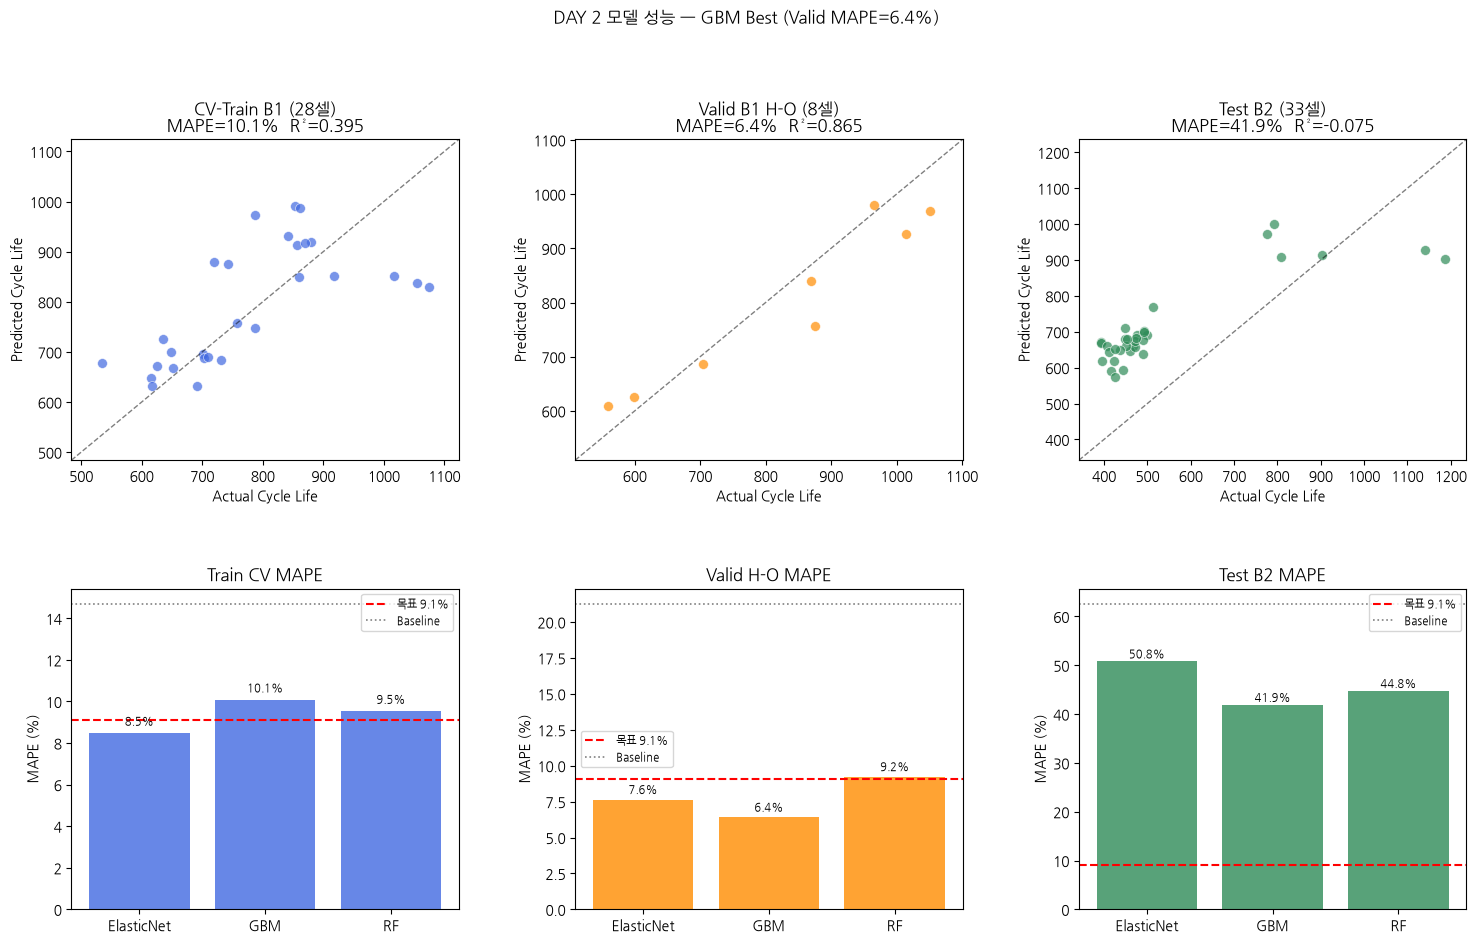

저장: results/day2_performance.png


In [5]:
best_r = results[best_name]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

sets = [
    (f'CV-Train B1 ({len(train_df)}셀)', y_train, best_r['cv']['pred'],    'royalblue'),
    (f'Valid B1 H-O ({len(valid_df)}셀)', y_valid, best_r['valid']['pred'], 'darkorange'),
    (f'Test B2 ({len(b2)}셀)',            y_test2, best_r['test2']['pred'], 'seagreen'),
]
for ax, (label, yt, yp, col) in zip(axes[0], sets):
    mape = mean_absolute_percentage_error(yt, yp) * 100
    r2   = r2_score(yt, yp)
    vmin = min(yt.min(), yp.min()) - 50
    vmax = max(yt.max(), yp.max()) + 50
    ax.plot([vmin, vmax], [vmin, vmax], 'k--', lw=1, alpha=0.5)
    ax.scatter(yt, yp, color=col, alpha=0.7, s=50, edgecolors='white', lw=0.5)
    ax.set_xlabel('Actual Cycle Life'); ax.set_ylabel('Predicted Cycle Life')
    ax.set_title(f'{label}\nMAPE={mape:.1f}%  R²={r2:.3f}')
    ax.set_xlim(vmin, vmax); ax.set_ylim(vmin, vmax)

mn = list(results.keys())
x  = np.arange(len(mn))
for ax, (vals, label, col) in zip(axes[1], [
    ([results[m]['cv']['mape']    for m in mn], 'Train CV MAPE',  'royalblue'),
    ([results[m]['valid']['mape'] for m in mn], 'Valid H-O MAPE', 'darkorange'),
    ([results[m]['test2']['mape'] for m in mn], 'Test B2 MAPE',   'seagreen'),
]):
    bars = ax.bar(x, vals, color=col, alpha=0.8)
    ax.axhline(TARGET_MAPE, color='red', linestyle='--', lw=1.5, label=f'목표 {TARGET_MAPE}%')
    ax.axhline(baseline['test2']['mape'] if 'B2' in label else
               baseline['valid']['mape'] if 'Valid' in label else
               baseline['cv']['mape'],
               color='gray', linestyle=':', lw=1.2, label='Baseline')
    ax.set_xticks(x); ax.set_xticklabels(mn)
    ax.set_ylabel('MAPE (%)'); ax.set_title(label); ax.legend(fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'DAY 2 모델 성능 — {best_name} Best (Valid MAPE={best_r["valid"]["mape"]:.1f}%)',
             fontsize=12, y=1.01)
plt.savefig(f'{OUT}/day2_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: results/day2_performance.png')

## 5. 피처 중요도 (RF)

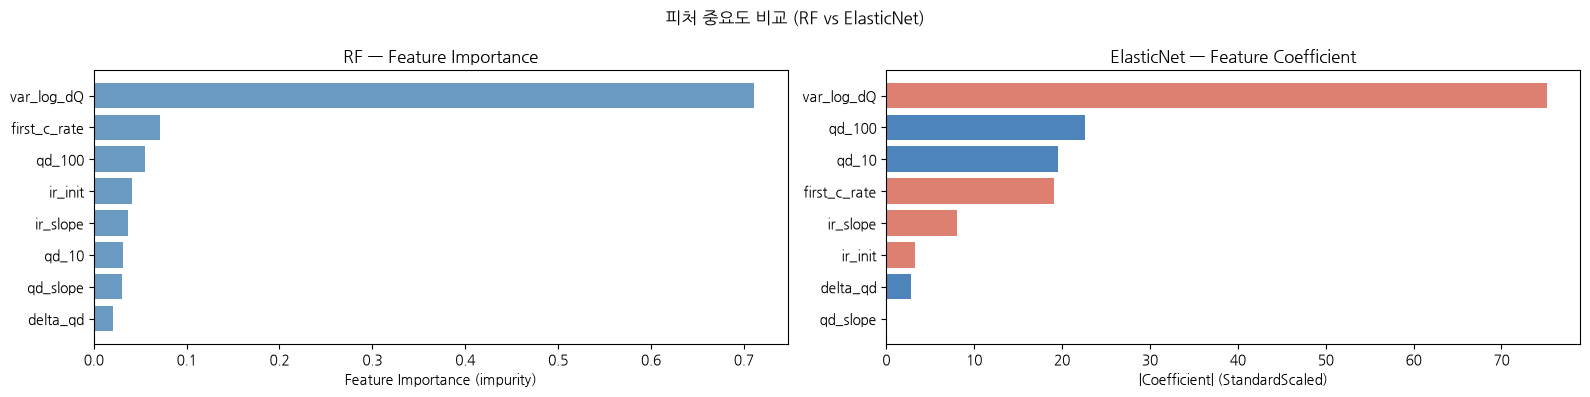


RF 중요도 순위:
  1. var_log_dQ: 0.7115
  2. first_c_rate: 0.0718
  3. qd_100: 0.0553
  4. ir_init: 0.0416
  5. ir_slope: 0.0369
  6. qd_10: 0.0312
  7. qd_slope: 0.0306
  8. delta_qd: 0.0211


In [6]:
rf_model = results['RF']['best_model']
importances = rf_model.feature_importances_
order = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# RF 피처 중요도
axes[0].barh(np.array(FEATURES)[order], importances[order], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Feature Importance (impurity)')
axes[0].set_title('RF — Feature Importance')
axes[0].invert_yaxis()

# ElasticNet 계수
en_model = results['ElasticNet']['best_model']
coefs = np.abs(en_model.coef_)
order_en = np.argsort(coefs)[::-1]
colors_bar = ['#2166ac' if c >= 0 else '#d6604d' for c in en_model.coef_[order_en]]
axes[1].barh(np.array(FEATURES)[order_en], coefs[order_en], color=colors_bar, alpha=0.8)
axes[1].set_xlabel('|Coefficient| (StandardScaled)')
axes[1].set_title('ElasticNet — Feature Coefficient')
axes[1].invert_yaxis()

plt.suptitle('피처 중요도 비교 (RF vs ElasticNet)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT}/day2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nRF 중요도 순위:')
for i, idx in enumerate(order):
    print(f'  {i+1}. {FEATURES[idx]}: {importances[idx]:.4f}')

## 6. 오류 분석 — 가장 크게 틀린 셀

=== Test B2 오류 상위 10개 셀 ===
 actual  predicted  abs_error  pct_error
 1186.0      902.8      283.2       23.9
  393.0      671.7      278.7       70.9
  392.0      668.5      276.5       70.5
  449.0      711.8      262.8       58.5
  514.0      768.9      254.9       49.6
  408.0      661.6      253.6       62.2
  412.0      644.7      232.7       56.5
  449.0      680.0      231.0       51.5
  452.0      680.5      228.5       50.6
  425.0      650.9      225.9       53.2

=== 수명 구간별 평균 MAPE ===
         mean  count
구간                  
<500     47.2     26
500-700  49.6      1
700-900  21.3      3
>900     14.5      3


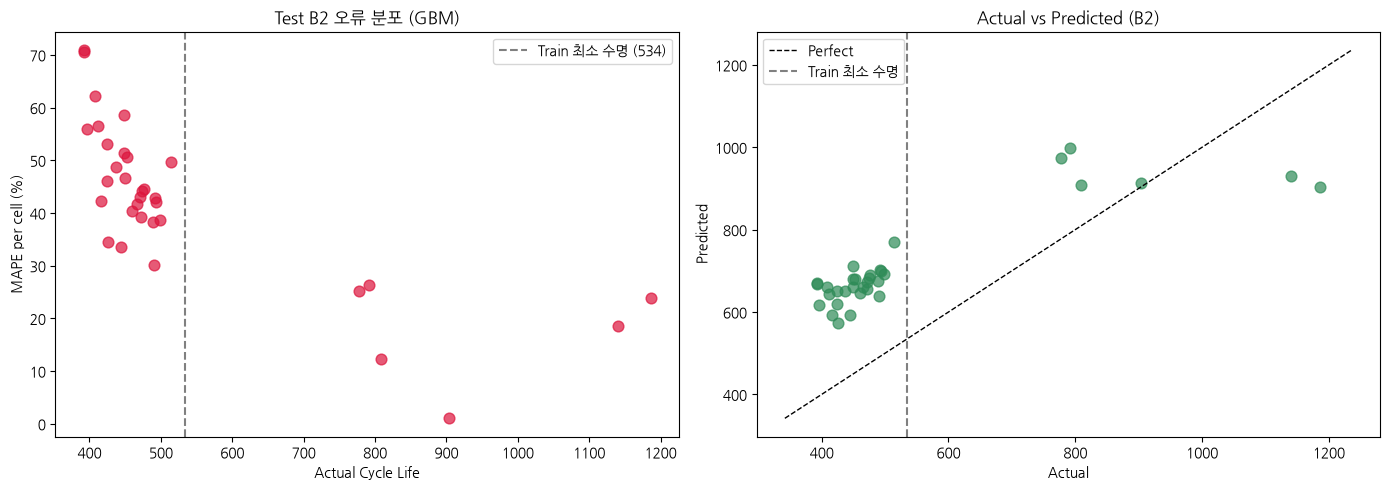

저장: results/error_analysis.png


In [7]:
import pandas as pd

best_r = results[best_name]
errors = pd.DataFrame({
    'actual':    y_test2,
    'predicted': best_r['test2']['pred'],
    'abs_error': np.abs(best_r['test2']['pred'] - y_test2),
    'pct_error': np.abs(best_r['test2']['pred'] - y_test2) / y_test2 * 100,
})

print('=== Test B2 오류 상위 10개 셀 ===')
print(errors.sort_values('abs_error', ascending=False).head(10).round(1).to_string(index=False))

print(f'\n=== 수명 구간별 평균 MAPE ===')
bins = [0, 500, 700, 900, 2000]
labels = ['<500', '500-700', '700-900', '>900']
errors['구간'] = pd.cut(errors['actual'], bins=bins, labels=labels)
print(errors.groupby('구간', observed=True)['pct_error'].agg(['mean','count']).round(1))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(errors['actual'], errors['pct_error'], alpha=0.7, color='crimson', s=60)
axes[0].axvline(534, color='gray', linestyle='--', lw=1.5, label='Train 최소 수명 (534)')
axes[0].set_xlabel('Actual Cycle Life'); axes[0].set_ylabel('MAPE per cell (%)')
axes[0].set_title(f'Test B2 오류 분포 ({best_name})')
axes[0].legend()

axes[1].scatter(errors['actual'], errors['predicted'], alpha=0.7, color='seagreen', s=60)
vmin = min(errors['actual'].min(), errors['predicted'].min()) - 50
vmax = max(errors['actual'].max(), errors['predicted'].max()) + 50
axes[1].plot([vmin, vmax], [vmin, vmax], 'k--', lw=1, label='Perfect')
axes[1].axvline(534, color='gray', linestyle='--', lw=1.5, label='Train 최소 수명')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs Predicted (B2)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUT}/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: results/error_analysis.png')

## 7. 결과 저장

In [8]:
summary = save_summary(
    results,
    split_info={'train_b1': len(train_df), 'valid_b1': len(valid_df),
                'test_b2': len(b2), 'test_b3': len(b3)},
    out_path=f'{OUT}/day2_summary.json',
    baseline=baseline,
)
print('저장: results/day2_summary.json, results/model_performance.csv')
print(f'best_model (Valid 기준): {summary["best_model"]}')

저장: results/day2_summary.json, results/model_performance.csv
best_model (Valid 기준): GBM
